In [1]:
%matplotlib widget

In [2]:
from calc import ThicknessCalculator
from calc import load_mrc
from draw import ThicknessViewer
import numpy as np

In [3]:
# Load density and mask
vol, pix = load_mrc('/home/art/Documents/TRPA1/apo_united/membrane_thickness_computation/nanodisk_wo_protein_for_analysis.mrc') # density used for analysis (only nanodisk, protein density is zeroed out)
mask3d, _ = load_mrc('/home/art/Documents/TRPA1/apo_united/membrane_thickness_computation/mask_for_protein_subtraction.mrc') # 3D mask excluding protein density (0 inside protein, 1 - outside)
calc = ThicknessCalculator(vol, pix, mask3d=mask3d)

In [4]:
# Optional step
# Will use density with protein to generate better intensity map
vol, pix = load_mrc('/home/art/Documents/TRPA1/apo_united/membrane_thickness_computation/cryosparc_P63_J332_map_aligned_1.mrc') # original density with protein
calc_with_protein = ThicknessCalculator(vol, pix)

In [5]:
calc.smooth(6/2.335) # smooth density by 6 Angstrom in XY-plane (but not in Z direction) to improve SNR
calc_with_protein.smooth(6/2.335) # same for density with protein

viewer = ThicknessViewer(calc)
viewer_with_protein = ThicknessViewer(calc_with_protein)

In [6]:
#viewer.plot_projection(method='mean', smoothed=False)


In [7]:
#viewer.interactive_slice_viewer(smoothed=True, init_z=192.56)

In [15]:
# Select region in Z direction containing ND density and choose threshold to generate intensity mask
viewer_with_protein.interactive_intensity_mask(init_z_range=[161,223], init_thresh=0.39, plot = False)

In [16]:
# Convert loaded 3D mask to 2D
viewer.interactive_mask_collapse(init_z_range=[164,204.73], init_thresh=0.2, plot = False)

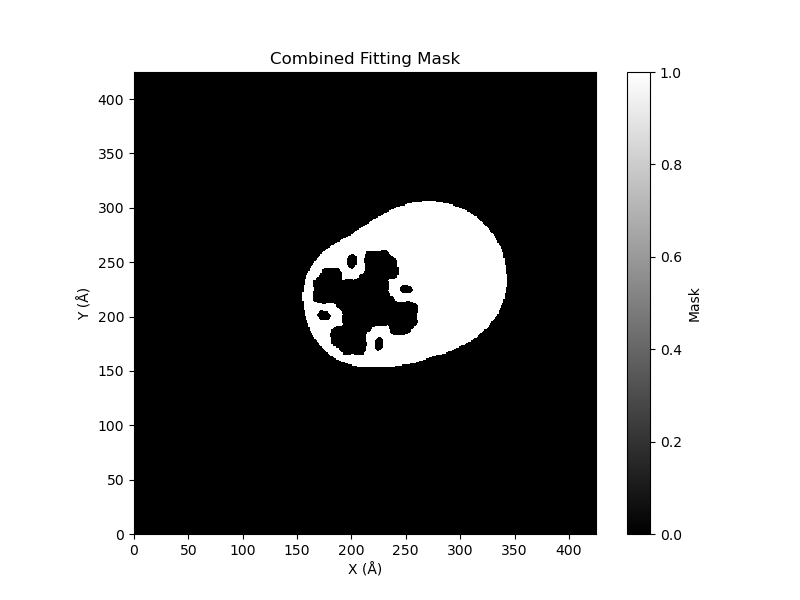

In [17]:
calc.intensity_mask_2d = calc_with_protein.intensity_mask_2d # substitude intensity mask generated from density with protein

viewer.create_combined_mask()

In [18]:
# Define initial guesses, parameter bounds, and z_bounds — all in angstroms
# Templates will be tried sequentially untill good fit is reached
calc.fit_templates = [
    (
        np.array([192, 23, 0.55, 0.55, 5, 5, 1,   1,    1.2, 1.2, 0.7, 0.7,   -0.25]),  # Initial guess
        np.array([187, 22, 0.45, 0.45, 4, 4, 0.5, 0.45, 0.8, 0.8, 0.5, 0.5,   -0.35]),  # Lower bounds
        np.array([197, 25, 0.7,  0.7,  8, 8, 1.2, 1.2,  1.4, 1.4, 0.9, 0.9,   -0.15]),  # Upper bounds
        (150, 235)  # z_bounds in Å
    ),
    (
        np.array([192, 15, 0.55, 0.55, 5, 5, 1,   1,    1,   1,   0.6, 0.1,  -0.25]),  # Initial guess
        np.array([187, 10, 0,    0,    3, 3, 0.5, 0,    0.6, 0.5, 0,   0  ,  -0.35]),  # Lower bounds
        np.array([197, 20, 0.9,  0.7,  8, 8, 1.4, 1.2,  1.4, 1.4, 0.8, 0.7,   0.1]),  # Upper bounds
        (150, 235)  # z_bounds in Å
    ),
    (
        np.array([192, 19, 0.45, 0.6, 7, 7, 1,   1,   0.7, 0.8,  0.8, 0.7,  -0.15]),  # Initial guess
        np.array([187, 16, 0.3,  0.4, 5, 5, 0.7, 0.9, 0.5, 0.5,  0,   0  ,  -0.35]),  # Lower bounds
        np.array([197, 21, 0.7,  0.8, 9, 9, 1.4, 1.7, 1.4, 1.4,  0.95, 0.8,   0.1]),  # Upper bounds
        (150, 225)  # z_bounds in Å
    ),
    (
        np.array([192, 15, 0.55, 0.55, 5, 5, 1,   1,    1,   1,   0.6, 0.1,  -0.25]),  # Initial guess
        np.array([187, 10, 0,    0,    3, 3, 0.5, 0,    0.6, 0.5, 0,   0  ,  -0.35]),  # Lower bounds
        np.array([197, 20, 0.9,  0.7,  8, 8, 1.4, 1.2,  1.4, 1.4, 0.8, 0.7,   0.1]),  # Upper bounds
        (150, 215)  # z_bounds in Å
    ),
    (
        np.array([192, 19, 0.5,  0.6,  4.5, 7, 1,   1,    0.8, 0.8, 0.8,  0.2,   0]),  # Initial guess
        np.array([187, 16, 0,    0,    3,   3, 0.5, 0,    0.4, 0.5, 0,    0  ,  -0.15]),  # Lower bounds
        np.array([197, 21, 0.8,  0.8,  8,   9, 1.6, 1.4,  1.4, 1.4, 1.7,  0.7,   0.25]),  # Upper bounds
        (165, 225)  # z_bounds in Å
    ),
    (
        np.array([192, 19, 0.5,  0.4,  5,   3,   1,     1,    0.8, 0.8, 0.8,  0.2,   0]),  # Initial guess
        np.array([187, 16, 0,    0,    3,   1.5, 0.5,   0,    0.4, 0.5, 0,    0  ,  -0.15]),  # Lower bounds
        np.array([197, 21, 0.9,  0.8,  9,   7,   5,     4,    1.4, 1.4, 1.7,  0.7,   0.25]),  # Upper bounds
        (165, 220)  # z_bounds in Å
    ),
    (
        np.array([192, 23, 0.55, 0.55, 5, 5, 1,   1,    1.2, 1.2, 0.7, 0.7,   -0.25]),  # Initial guess
        np.array([187, 20, 0.45, 0.45, 4, 4, 0.5, 0.45, 0.8, 0.8, 0.5, 0.5,   -0.35]),  # Lower bounds
        np.array([197, 25, 0.7,  0.7,  8, 8, 1.2, 1.2,  1.4, 1.4, 0.9, 0.9,   -0.15]),  # Upper bounds
        (150, 223)  # z_bounds in Å
    ),
    (
        np.array([190, 6,  0.01, 0.01,   4,   4,    1 ,    1,    0.7, 0.7,  0.01, 0.01, 0.3]),  # Initial guess
        np.array([185, 5,  0,    0,      2.5, 2.5,  0.5,   0.5,  0.4, 0.4,  0,   0  ,  -0.1]),  # Lower bounds
        np.array([197, 8,  0.2,  0.1,    6,   6.5,  1.5,   1.5,  1,   0.9,  0.1, 0.1,   0.6]),  # Upper bounds
        (177, 202)  # z_bounds in Å
    ),
]


In [31]:
# Test at one point
# Note, final fit will not be exectly the same as optimiser will compute approximate Hessian for the whole batch rather then point by point

#viewer.plot_profile_point(191, 264, template_idx=1, full_range=0, reg_lambda = 0.05,)

In [22]:
# Compute nanodisk thickness
calc.compute_thickness(max_rmse=0.16, reg_lambda = 0.05, tol = 5e-4, amp_threshold = 0.05)

[191.87723467  23.69114233   0.55578077   0.58847612   5.44647801
   5.34191276   1.01064545   1.03111187   1.14572964   1.08469141
   0.77547158   0.83053451  -0.2315366 ]
Fit at (300.0Å, 260.0Å), tpl=0:
  Peak1: z=168.19Å, σ=5.45Å, A=1.15
  Peak2: z=215.57Å, σ=5.34Å, A=1.08
  Peak3: z=181.35Å, σ=5.50Å, A=0.89
  Peak4: z=201.63Å, σ=5.51Å, A=0.90
  Offset=-0.23; Thickness=47.38Å


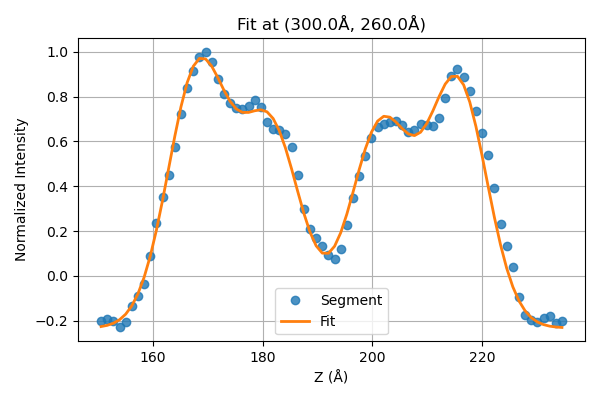

<Axes: title={'center': 'Fit at (300.0Å, 260.0Å)'}, xlabel='Z (Å)', ylabel='Normalized Intensity'>

In [ ]:
# Diagnostics

#viewer.plot_map('width_sigma')
#viewer.plot_map('template_map')
#viewer.plot_profile_from_map(300, 260, full_range=0)

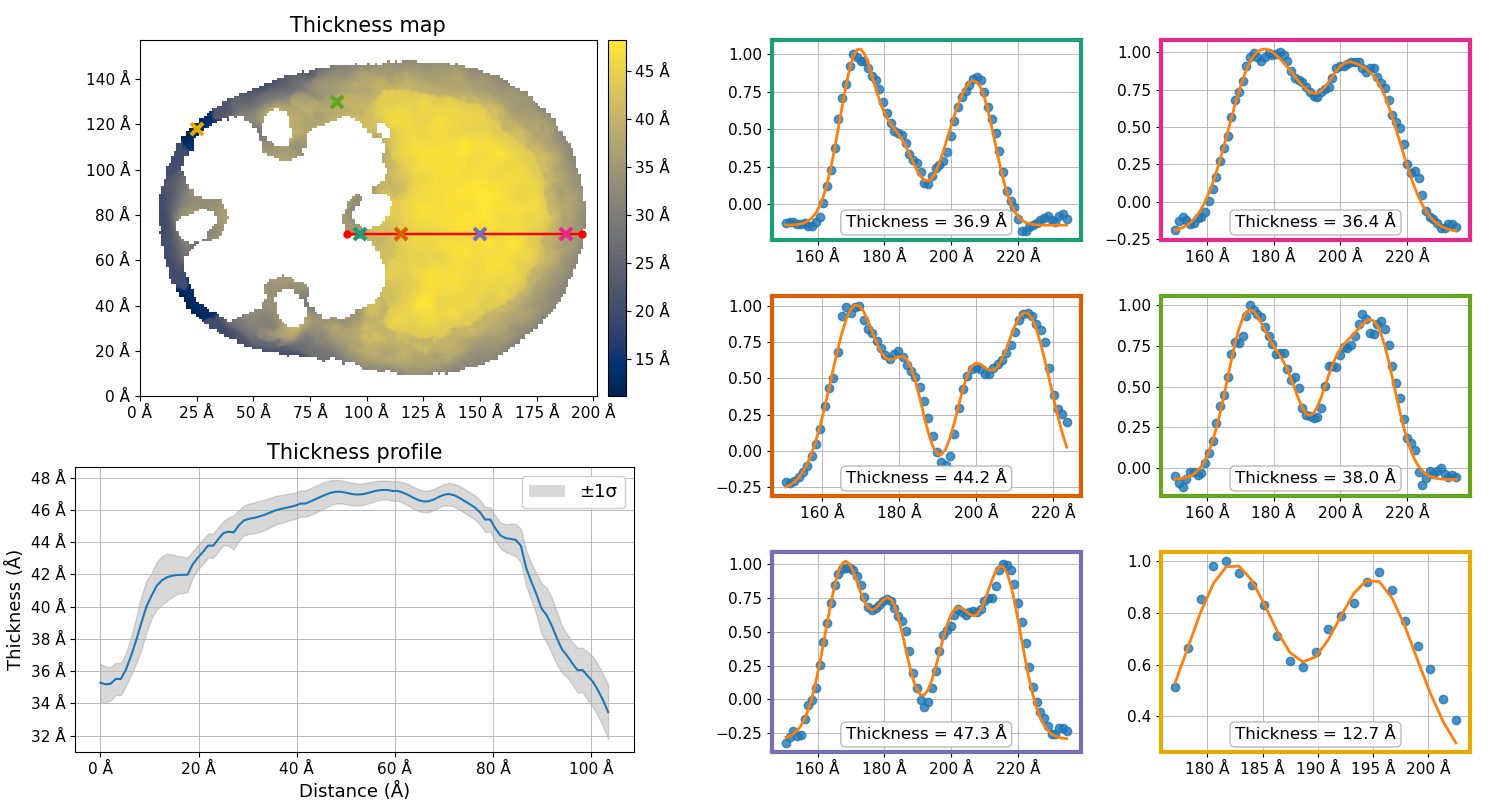

In [32]:
from plot import make_panel

fig, meta = make_panel(
    calc=calc,
    p0=(91.5, 71.5), p1=(195, 71.5),
    profile_points=[(97,71.5), (115,71.5), (150,71.5), (188,71.5), (87,130), (25,118)],
    viewer=viewer,
    sigma_thresh=5,
    mirror_axis='y',
    rotation_angle=-22,
    x_range=[150, 350], y_range=[135, 290],
    # ... optional visual overrides ...
    cmap_map='cividis',
    left_right_widths=(0.8, 1),
    left_height_fracs=(1, 0.8),
    annotate_profile_numbers=False,
    suppress_profile_legends=True,
    suppress_profile_titles=True,
    map_marker_style='x',
    map_marker_size=8,
    map_marker_linewidth=3.0,
    figsize=(15, 8),
    dpi=100,
    title_fontsize=15,
    label_fontsize=13,
    tick_labelsize=11,
    profile_spine_linewidth=3,
    profile_thickness_fontsize=12,
    thickness_legend_fontsize=13,
    #savepath='/home/art/Documents/TRPA1/2026_pictures/2D_thickness_map_panel_v3.png',
)